# Revenue Prediction Model

## Objective

Predict the future revenue of each customer using historical transaction data.

This is a **regression problem**, where the target is a continuous numerical value.

## Business Goal

Estimate how much each customer is expected to spend in the future.

In [3]:
import pandas as pd

revenue_dataset = pd.read_csv("../data/processed/revenue_dataset.csv")

revenue_dataset.head()

,CustomerID,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value,future_revenue
0,12346.0,235,2,0.00,0,1,0.000000,0.00
1,12347.0,39,5,2790.86,1590,82,558.172000,1519.14
2,12348.0,158,3,1487.24,2124,22,495.746667,310.00
3,12350.0,220,1,334.40,197,17,334.400000,0.00
4,12352.0,172,8,601.18,188,26,75.147500,944.23


In [2]:
revenue_dataset.describe()

,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value,future_revenue
count,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000
mean,94.374853,4.221571,1504.247785,897.360199,49.525791,305.371662,759.890147
std,80.729272,7.091199,5719.389332,3539.167616,67.623830,360.309138,3937.383722
min,1.000000,1.000000,-4287.630000,-1363.000000,1.000000,-4287.630000,-468.320000
25%,24.750000,1.000000,248.287500,125.000000,13.000000,143.503125,0.000000
50%,73.000000,2.000000,540.775000,300.500000,29.000000,228.011417,164.230000
75%,151.000000,5.000000,1329.410000,760.000000,62.000000,353.262500,671.932500
max,283.000000,139.000000,177585.620000,127548.000000,1240.000000,5629.751667,124206.550000


In [4]:
# Features and target
X = revenue_dataset.drop("future_revenue", axis=1)
y = revenue_dataset["future_revenue"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3412, 7)
y shape: (3412,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2729, 7)
Test size: (683, 7)


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lin_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lin_reg.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [6]:
y_train_pred = lin_reg.predict(X_train)

print("Predictions:", y_train_pred[:5])
print("Actual:", y_train.iloc[:5].values)

Predictions: [1270.76446737  793.98047426  214.07912774  259.27706418  157.24317051]
Actual: [1185.01  972.13    0.      0.      0.  ]


In [7]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(y_train, y_train_pred)

print("Linear Regression RMSE:", lin_rmse)

Linear Regression RMSE: 1812.2748517309128


In [8]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [9]:
y_train_pred_tree = tree_reg.predict(X_train)

tree_rmse = root_mean_squared_error(y_train, y_train_pred_tree)

print("Decision Tree RMSE:", tree_rmse)

Decision Tree RMSE: 2.7764049824483784e-17


The Decision Tree model achieved near-zero RMSE on the training set, indicating severe overfitting. The model memorized the training data instead of learning general patterns.

In [10]:
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

tree_scores = cross_val_score(
    tree_reg,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

tree_rmse_scores = -tree_scores

print(pd.Series(tree_rmse_scores).describe())

count       5.000000
mean     2612.150328
std      1088.020244
min      1379.631170
25%      1795.241528
50%      2441.652586
75%      3555.373542
max      3888.852812
dtype: float64


In [11]:
lin_scores = cross_val_score(
    lin_reg,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

lin_rmse_scores = -lin_scores

print(pd.Series(lin_rmse_scores).describe())

count       5.000000
mean     1910.752829
std       676.515727
min      1124.135549
25%      1637.773842
50%      1769.249446
75%      2066.293413
max      2956.311897
dtype: float64


The Decision Tree model shows significantly higher RMSE during cross-validation compared to its near-zero training error, indicating severe overfitting. In contrast, Linear Regression achieves lower and more stable RMSE, suggesting better generalization.

In [12]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)

forest_scores = cross_val_score(
    forest_reg,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

forest_rmse_scores = -forest_scores

print(pd.Series(forest_rmse_scores).describe())

count       5.000000
mean     2382.823748
std       869.732070
min      1320.169152
25%      1607.858306
50%      2696.221642
75%      3010.613468
max      3279.256174
dtype: float64


Linear Regression outperformed both Decision Tree and Random Forest models, achieving the lowest RMSE and more stable performance. This suggests that the underlying relationships in the data are relatively linear, and more complex models tend to overfit.

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(random_state=42)

In [14]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "max_features": [2, 4, 6]
}

In [15]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': [2, 4, ...], 'n_estimators': [100, 200]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [16]:
print("Best Params:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best Params: {'max_depth': 20, 'max_features': 6, 'n_estimators': 200}
Best CV RMSE: 2323.265750925959


In [17]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import root_mean_squared_error

best_rf = grid_search.best_estimator_

cv_predictions = cross_val_predict(best_rf, X_train, y_train, cv=5)
cv_rmse = root_mean_squared_error(y_train, cv_predictions)

print("Cross-validated prediction RMSE:", cv_rmse)

Cross-validated prediction RMSE: 2444.1809986824455


After hyperparameter tuning, Random Forest improved slightly compared to its default configuration, but it still underperformed Linear Regression. The best tuned Random Forest achieved a cross-validation RMSE of about 2323, which remains worse than Linear Regression’s RMSE of about 1911. This suggests that, with the current feature set, the simpler linear model generalizes better than the more complex ensemble model.

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [19]:
param_distributions = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(5, 30),
    "max_features": randint(2, 6)
}

In [20]:
rnd_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

In [21]:
rnd_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....00128AE9A6A70>, 'max_features': <scipy.stats....001289843B940>, 'n_estimators': <scipy.stats....00128AE8D1E10>}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
print("Best Params:", rnd_search.best_params_)
print("Best CV RMSE:", -rnd_search.best_score_)


Best Params: {'max_depth': 5, 'max_features': 5, 'n_estimators': 413}
Best CV RMSE: 2294.9663097431157


In [23]:
best_rf_rnd = rnd_search.best_estimator_

In [24]:
rf_scores = cross_val_score(
    best_rf_rnd,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

rf_rmse_scores = -rf_scores

The best-performing Random Forest model had a shallow depth (max_depth=5), indicating that simpler structures generalize better on this dataset. Even after extensive hyperparameter tuning using both Grid Search and Randomized Search, Random Forest failed to outperform Linear Regression. This suggests that the underlying relationships in the data may be relatively simple or that the current feature set does not support complex nonlinear modeling.

Bagging was conceptually explored as an ensemble technique that reduces variance by training multiple models on random subsets of the data. However, since Random Forest is an improved version of bagging (with additional feature randomness), we directly used Random Forest in our experiments.

In [25]:
from sklearn.ensemble import ExtraTreesRegressor

In [26]:
etr = ExtraTreesRegressor(random_state=42)

etr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [27]:
from sklearn.model_selection import cross_val_score
import pandas as pd

etr_scores = cross_val_score(
    etr,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

etr_rmse = -etr_scores

print(pd.Series(etr_rmse).describe())

count       5.000000
mean     2191.872898
std       679.993537
min      1208.109585
25%      1963.373207
50%      2355.979848
75%      2360.060612
max      3071.841237
dtype: float64


Extra Trees improved over Random Forest due to increased randomness, which helped reduce variance. However, it still underperformed compared to Linear Regression, indicating that the dataset may not benefit significantly from complex tree-based ensemble models.

In [28]:
feature_importance = pd.Series(
    best_rf_rnd.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

monetary_total      0.672244
total_items         0.175338
unique_products     0.052083
avg_order_value     0.037782
recency_days        0.034327
frequency_orders    0.028226
dtype: float64


<Axes: >

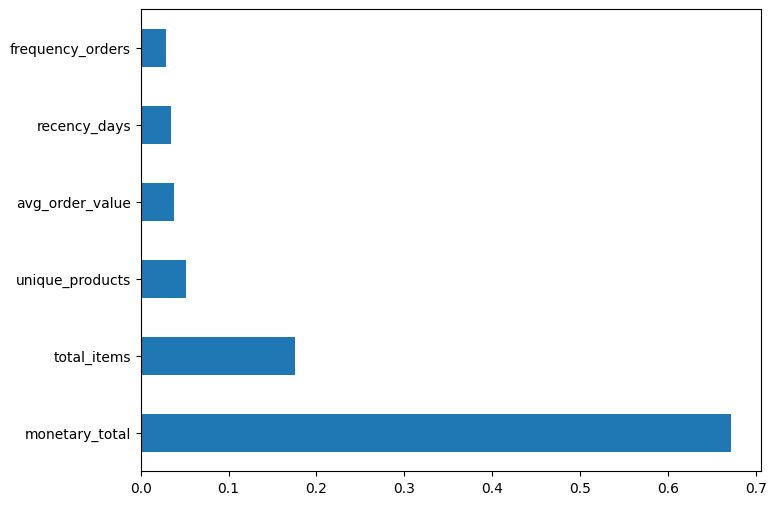

In [29]:
feature_importance.plot(kind='barh', x='feature', y='importance', figsize=(8,6))

Feature importance analysis revealed that monetary_total is by far the most influential feature, contributing over 67% of the model’s decision-making. This indicates that historical spending is the strongest predictor of future revenue. In contrast, behavioral features such as recency and frequency had relatively low importance, suggesting that total value is more critical than temporal activity patterns in this dataset.

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    learning_rate=0.05,
    n_estimators=500,
    max_depth=2,
    random_state=42
)

gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [31]:
from sklearn.model_selection import cross_val_score
import pandas as pd

gbr_scores = cross_val_score(
    gbr,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

gbr_rmse = -gbr_scores

print(pd.Series(gbr_rmse).describe())

count       5.000000
mean     2050.950316
std       786.382086
min       967.590946
25%      1668.411521
50%      2197.079403
75%      2349.355419
max      3072.314291
dtype: float64


In [32]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd

gbr_es = GradientBoostingRegressor(
    learning_rate=0.05,
    n_estimators=500,
    max_depth=2,
    n_iter_no_change=10,
    random_state=42
)

gbr_es.fit(X_train, y_train)

gbr_es_scores = cross_val_score(
    gbr_es,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

gbr_es_rmse = -gbr_es_scores

print("Actual estimators used:", gbr_es.n_estimators_)
print(pd.Series(gbr_es_rmse).describe())

Actual estimators used: 11
count       5.000000
mean     2635.284411
std      1137.086793
min      1147.532494
25%      1684.459956
50%      3243.595385
75%      3481.807255
max      3619.026968
dtype: float64


Although Gradient Boosting showed improvement after manual tuning, it still did not outperform Linear Regression. Early stopping led to underfitting due to premature termination of training. This indicates that the dataset has relatively simple underlying relationships, making Linear Regression the most suitable model.

Although stacking is a powerful ensemble technique that combines multiple models, it was not applied in this project since Linear Regression significantly outperformed all other models. Using stacking in this case could increase model complexity without guaranteeing performance improvement.

In [33]:
import pandas as pd
import numpy as np


results = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],
    "Mean RMSE": [
        np.mean(lin_rmse_scores),
        np.mean(rf_rmse_scores),
        np.mean(etr_rmse),
        np.mean(gbr_rmse)
    ],
    "Std RMSE": [
        np.std(lin_rmse_scores),
        np.std(rf_rmse_scores),
        np.std(etr_rmse),
        np.std(gbr_rmse)
    ]
}

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(by="Mean RMSE")

print(df_results)

               Model    Mean RMSE    Std RMSE
0  Linear Regression  1910.752829  605.094062
3  Gradient Boosting  2050.950316  703.361520
2        Extra Trees  2191.872898  608.204709
1      Random Forest  2294.966310  739.502035


The comparison shows that Linear Regression achieved the lowest RMSE and demonstrated more stable performance compared to ensemble models such as Random Forest, Extra Trees, and Gradient Boosting. This indicates that the underlying relationships in the data are relatively simple and linear. More complex models introduced additional variance without improving performance, suggesting overfitting tendencies.

In [34]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import pandas as pd

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_train)

lin = LinearRegression()

scores = cross_val_score(
    lin,
    X_poly,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

rmse = -scores

print(pd.Series(rmse).describe())

count       5.000000
mean     5070.278532
std      2822.460672
min      1662.586083
25%      3878.984188
50%      3903.378901
75%      7301.604887
max      8604.838600
dtype: float64


## Polynomial Result

 Polynomial feature expansion was tested to capture potential nonlinear relationships. However, it significantly degraded performance, indicating that the underlying relationships in the dataset are primarily linear and that additional complexity leads to overfitting.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import pandas as pd

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

print("Best alpha:", ridge_search.best_params_)
print("Best CV RMSE:", -ridge_search.best_score_)

Best alpha: {'model__alpha': 0.01}
Best CV RMSE: 1910.7943486655167


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000))
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_search = GridSearchCV(
    lasso_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

print("Best alpha:", lasso_search.best_params_)
print("Best CV RMSE:", -lasso_search.best_score_)

Best alpha: {'model__alpha': 0.001}
Best CV RMSE: 1910.7556002290949


## Regularization Result

Ridge and Lasso did not improve performance (RMSE stayed ~1910).

Both chose very small alpha values → no need for regularization.

✅ Linear Regression is already optimal.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

lin_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


lin_reg.fit(X_train, y_train)


y_pred = lin_reg.predict(X_test)


test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)

Test RMSE: 2516.8250704223115
Test MAE: 622.302879902403


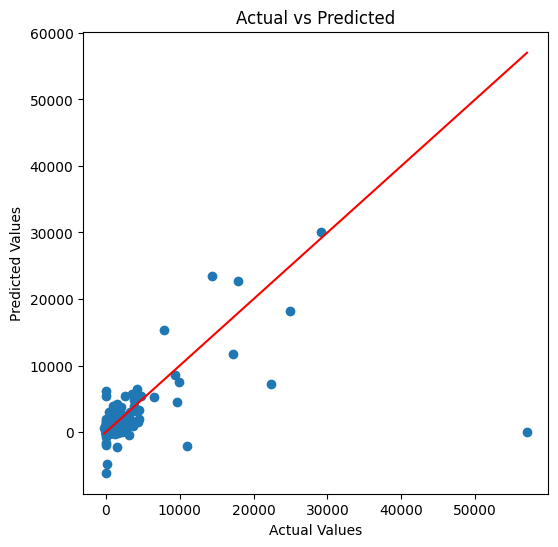

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

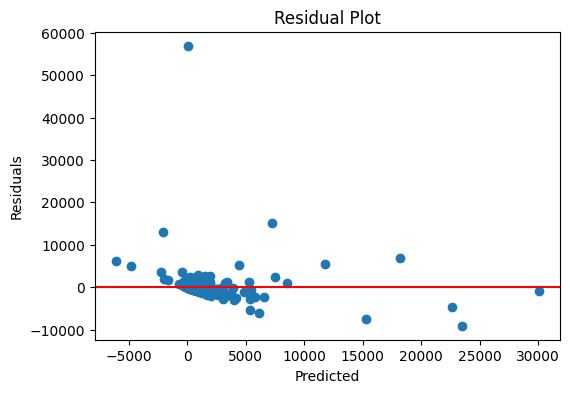

In [40]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

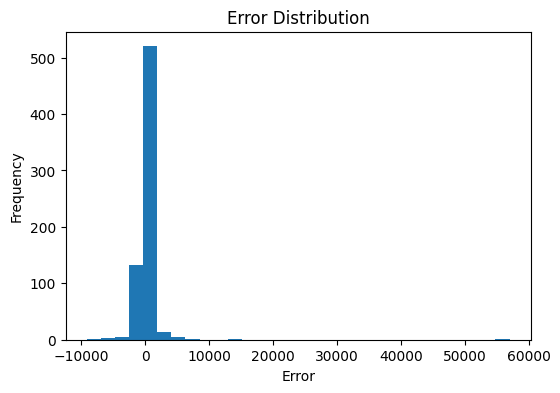

In [41]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)

plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()